In [347]:
import pandas as pd

url = "https://data.insideairbnb.com/the-netherlands/north-holland/amsterdam/2026-06-15/data/listings.csv.gz"
df_airbnb = pd.read_csv(url, compression='gzip')

print(df_airbnb.shape)
df_airbnb.head()

(10369, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,28871,https://www.airbnb.com/rooms/28871,20260615212022,2026-06-16,previous scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,NaN,https://a0.muscache.com/pictures/160889/362340...,124245,...,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,NaN,2,0,2,0,4.15
1,29051,https://www.airbnb.com/rooms/29051,20260615212022,2026-06-16,previous scrape,Comfortable single / double room,This room can also be rented as a single or a ...,NaN,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.93,4.88,4.79,0363 607B EA74 0BD8 2F6F,NaN,2,0,2,0,4.88
2,44129,https://www.airbnb.com/rooms/44129,20260615212022,2026-06-24,previous scrape,Luxury design with canal view,"Welcome to my little gem<br /><br />Cozy, brig...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,187728,...,4.89,4.95,4.59,03635399E87602900F47,NaN,4,3,1,0,0.96
3,44391,https://www.airbnb.com/rooms/44391,20260615212022,2026-06-24,previous scrape,Quiet 2-bedroom Amsterdam city centre apartment,Guests greatly appreciate the unique location ...,NaN,https://a0.muscache.com/pictures/97741545/3900...,194779,...,4.90,4.68,4.50,0363 E76E F06A C1DD 172C,NaN,1,1,0,0,0.22
4,48373,https://www.airbnb.com/rooms/48373,20260615212022,2026-06-24,previous scrape,Cozy family home in Amsterdam South,Charming modern apartment in the quiet and gre...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,220434,...,5.00,4.60,5.00,0363 4A2B A6AD 0196 F684,NaN,1,1,0,0,0.14


In [446]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error  
)
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [349]:
df_airbnb.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

In [350]:
df_airbnb.isnull().sum()

id                                                 0
listing_url                                        0
scrape_id                                          0
last_scraped                                       0
source                                             0
                                                ... 
calculated_host_listings_count                     0
calculated_host_listings_count_entire_homes        0
calculated_host_listings_count_private_rooms       0
calculated_host_listings_count_shared_rooms        0
reviews_per_month                               1023
Length: 90, dtype: int64

In [351]:
missing = df_airbnb.isnull().sum()
missing_percent = (missing / len(df_airbnb) * 100)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))

                              Missing Count  Percentage
neighborhood_overview                 10369  100.000000
host_since                            10369  100.000000
host_total_listings_count             10369  100.000000
neighbourhood                         10369  100.000000
host_verifications                    10369  100.000000
host_response_rate                    10369  100.000000
host_acceptance_rate                  10369  100.000000
host_thumbnail_url                    10369  100.000000
host_response_time                    10369  100.000000
host_neighbourhood                    10369  100.000000
instant_bookable                      10369  100.000000
calendar_updated                      10369  100.000000
neighbourhood_group_cleansed          10369  100.000000
host_about                             4959   47.825248
bathrooms                              4956   47.796316
beds                                   4652   44.864500
price_quote_total_price                3992   38

In [352]:
# Drop columns that have more than 50% missing values
df_airbnb= df_airbnb.dropna(thresh=len(df_airbnb) * 0.5, axis=1)

In [353]:
df_airbnb = df_airbnb.drop(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source'], axis=1)

In [354]:
df_airbnb= df_airbnb.drop(columns=['host_about'])

In [355]:
df_airbnb.shape

(10369, 71)

In [356]:
df_airbnb

,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,hosts_time_as_user_years,hosts_time_as_user_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,Comfortable double room,Basic bedroom in the center of Amsterdam.,https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,1.462510e+18,https://www.airbnb.com/users/profile/146251020...,Edwin,16.0,1.0,...,4.94,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,2,0,2,0,4.15
1,Comfortable single / double room,This room can also be rented as a single or a ...,https://a0.muscache.com/pictures/162009/bd6be2...,124245,https://www.airbnb.com/users/show/124245,1.462510e+18,https://www.airbnb.com/users/profile/146251020...,Edwin,16.0,1.0,...,4.93,4.93,4.88,4.79,0363 607B EA74 0BD8 2F6F,2,0,2,0,4.88
2,Luxury design with canal view,"Welcome to my little gem<br /><br />Cozy, brig...",https://a0.muscache.com/pictures/hosting/Hosti...,187728,https://www.airbnb.com/users/show/187728,1.462512e+18,https://www.airbnb.com/users/profile/146251212...,Tanya,15.0,10.0,...,4.89,4.89,4.95,4.59,03635399E87602900F47,4,3,1,0,0.96
3,Quiet 2-bedroom Amsterdam city centre apartment,Guests greatly appreciate the unique location ...,https://a0.muscache.com/pictures/97741545/3900...,194779,https://www.airbnb.com/users/show/194779,1.462512e+18,https://www.airbnb.com/users/profile/146251233...,Jan,15.0,10.0,...,4.95,4.90,4.68,4.50,0363 E76E F06A C1DD 172C,1,1,0,0,0.22
4,Cozy family home in Amsterdam South,Charming modern apartment in the quiet and gre...,https://a0.muscache.com/pictures/miso/Hosting-...,220434,https://www.airbnb.com/users/show/220434,1.462513e+18,https://www.airbnb.com/users/profile/146251300...,Vesna & Misha,15.0,9.0,...,5.00,5.00,4.60,5.00,0363 4A2B A6AD 0196 F684,1,1,0,0,0.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10364,Lovely room with balcony in the heart of Amste...,The apartment is on the first floor of a charm...,https://a0.muscache.com/pictures/hosting/Hosti...,1705253369814659132,https://www.airbnb.com/users/show/170525336981...,1.705254e+18,https://www.airbnb.com/users/profile/170525370...,Steven,0.0,0.0,...,NaN,NaN,NaN,NaN,0363 8C4D 1A2F 4D51 9B6C,7,2,5,0,NaN
10365,Keizers Canal Home,Welcome in our beautiful 100m2 canal house in ...,https://a0.muscache.com/pictures/miso/Hosting-...,481069764,https://www.airbnb.com/users/show/481069764,1.470166e+18,https://www.airbnb.com/users/profile/147016641...,Cornelia,3.0,8.0,...,NaN,NaN,NaN,NaN,0363 31C4 7BD8 1F63 4A61,2,2,0,0,NaN
10366,Two bedroom apt in the best location of Amsterdam,The apartment is on the first floor of a charm...,https://a0.muscache.com/pictures/hosting/Hosti...,1705253369814659132,https://www.airbnb.com/users/show/170525336981...,1.705254e+18,https://www.airbnb.com/users/profile/170525370...,Steven,0.0,0.0,...,NaN,NaN,NaN,NaN,0363 8C4D 1A2F 4D51 9B6C,7,2,5,0,NaN
10367,Single Bedroom apt in the heart of Amsterdam,The apartment is on the first floor of a charm...,https://a0.muscache.com/pictures/hosting/Hosti...,1705253369814659132,https://www.airbnb.com/users/show/170525336981...,1.705254e+18,https://www.airbnb.com/users/profile/170525370...,Steven,0.0,0.0,...,NaN,NaN,NaN,NaN,036302DC0A50A5E48A8A,7,2,5,0,NaN


In [357]:
df_airbnb[['price_quote_total_price', 'price', 'price_quote_price_per_night']].head(20)

,price_quote_total_price,price,price_quote_price_per_night
0,188.00,$94.00,94.00
1,NaN,NaN,NaN
2,941.00,$313.67,313.67
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,880.53,$440.27,440.27
6,1724.00,$574.67,574.67
7,154.06,$154.06,154.06
8,NaN,NaN,NaN
9,NaN,NaN,NaN


In [358]:
#Drop missing rows
df_airbnb = df_airbnb.dropna(subset=['price', 'price_quote_total_price', 'price_quote_price_per_night'])

In [359]:
#Check null values
df_airbnb[['price', 'price_quote_total_price', 'price_quote_price_per_night']].isnull().sum()

price                          0
price_quote_total_price        0
price_quote_price_per_night    0
dtype: int64

In [360]:
#Dropping Price column because it's same as price_quote_price_per_night
df_airbnb= df_airbnb.drop(['price'],axis=1)

In [361]:
df_airbnb.columns

Index(['name', 'description', 'picture_url', 'host_id', 'host_url',
       'host_profile_id', 'host_profile_url', 'host_name',
       'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_is_superhost', 'host_picture_url',
       'host_listings_count', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price_quote_checkin_date',
       'price_quote_checkout_date', 'price_quote_total_price',
       'price_quote_price_per_night', 'price_quote_raw', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availabili

In [362]:
missing = df_airbnb.isnull().sum()
missing_percent = (missing / len(df_airbnb) * 100)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))

                             Missing Count  Percentage
bathrooms                             1066   16.716324
host_location                         1040   16.308609
bedrooms                               913   14.317077
beds                                   767   12.027599
review_scores_accuracy                 637    9.989023
review_scores_checkin                  637    9.989023
review_scores_cleanliness              637    9.989023
review_scores_location                 637    9.989023
first_review                           637    9.989023
review_scores_value                    637    9.989023
reviews_per_month                      637    9.989023
review_scores_rating                   637    9.989023
last_review                            637    9.989023
review_scores_communication            637    9.989023
description                            308    4.829857
license                                154    2.414929
host_profile_id                        138    2.164027
hosts_time

In [363]:
df_airbnb[['room_type']].isnull().sum()

room_type    0
dtype: int64

In [364]:
# Fill missing bathrooms using the median of that specific room_type
df_airbnb['bathrooms'] = df_airbnb.groupby('room_type')['bathrooms'].transform(lambda x: x.fillna(x.median()))
# Fill missing beds using the median
df_airbnb['beds'] = df_airbnb.groupby('room_type')['beds'].transform(lambda x: x.fillna(x.median()))

In [365]:
df_airbnb[['review_scores_accuracy',              
'review_scores_checkin',              
'review_scores_cleanliness',           
'review_scores_location',                 
'first_review',                           
'review_scores_value',                   
'reviews_per_month',                   
'review_scores_rating',                  
'last_review',                   
'review_scores_communication'  ]]

,review_scores_accuracy,review_scores_checkin,review_scores_cleanliness,review_scores_location,first_review,review_scores_value,reviews_per_month,review_scores_rating,last_review,review_scores_communication
0,4.89,4.94,4.84,4.93,2010-08-22,4.83,4.15,4.86,2026-06-01,4.94
2,4.81,4.89,4.88,4.95,2010-08-16,4.59,0.96,4.88,2026-04-30,4.89
5,4.93,4.96,4.94,4.98,2010-10-29,4.79,3.45,4.94,2026-06-07,4.97
6,4.90,4.83,4.82,4.67,2010-10-13,4.75,0.98,4.86,2026-06-04,4.77
7,4.88,4.85,4.82,4.93,2011-01-04,4.80,3.35,4.86,2026-05-31,4.84
...,...,...,...,...,...,...,...,...,...,...
10364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [366]:
review_sub_score= ['review_scores_accuracy',              
'review_scores_checkin',              
'review_scores_cleanliness',           
'review_scores_location',                                      
'review_scores_value',                                                                       
'review_scores_communication']

df_airbnb= df_airbnb.drop(columns=review_sub_score)

In [367]:
missing = df_airbnb.isnull().sum()
missing_percent = (missing / len(df_airbnb) * 100)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))

                           Missing Count  Percentage
host_location                       1040   16.308609
bedrooms                             913   14.317077
review_scores_rating                 637    9.989023
first_review                         637    9.989023
reviews_per_month                    637    9.989023
last_review                          637    9.989023
description                          308    4.829857
license                              154    2.414929
host_name                            138    2.164027
hosts_time_as_host_years             138    2.164027
host_profile_id                      138    2.164027
host_has_profile_pic                 138    2.164027
host_picture_url                     138    2.164027
hosts_time_as_host_months            138    2.164027
host_is_superhost                    138    2.164027
hosts_time_as_user_years             138    2.164027
hosts_time_as_user_months            138    2.164027
host_identity_verified               138    2.

In [368]:
df_airbnb.columns

Index(['name', 'description', 'picture_url', 'host_id', 'host_url',
       'host_profile_id', 'host_profile_url', 'host_name',
       'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_is_superhost', 'host_picture_url',
       'host_listings_count', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price_quote_checkin_date',
       'price_quote_checkout_date', 'price_quote_total_price',
       'price_quote_price_per_night', 'price_quote_raw', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availabili

In [369]:
df_airbnb[['picture_url', 'host_id', 'host_url',
       'host_profile_id', 'host_profile_url', 'host_name',
       'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_is_superhost', 'host_picture_url',
       'host_listings_count', 'host_has_profile_pic', 'host_identity_verified',]]

,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_is_superhost,host_picture_url,host_listings_count,host_has_profile_pic,host_identity_verified
0,https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,1.462510e+18,https://www.airbnb.com/users/profile/146251020...,Edwin,16.0,1.0,15.0,5.0,"Amsterdam, The Netherlands",t,https://a0.muscache.com/im/pictures/user/9986b...,2.0,t,t
2,https://a0.muscache.com/pictures/hosting/Hosti...,187728,https://www.airbnb.com/users/show/187728,1.462512e+18,https://www.airbnb.com/users/profile/146251212...,Tanya,15.0,10.0,15.0,5.0,"Amsterdam, The Netherlands",t,https://a0.muscache.com/im/users/187728/profil...,6.0,t,t
5,https://a0.muscache.com/pictures/a6d6d2ee-3196...,225987,https://www.airbnb.com/users/show/225987,1.462513e+18,https://www.airbnb.com/users/profile/146251315...,Joanna & MP,15.0,9.0,15.0,5.0,"Amsterdam, The Netherlands",t,https://a0.muscache.com/im/pictures/user/User-...,1.0,t,t
6,https://a0.muscache.com/pictures/677876/7cb949...,230246,https://www.airbnb.com/users/show/230246,1.462513e+18,https://www.airbnb.com/users/profile/146251325...,Donald,15.0,9.0,15.0,5.0,"Amsterdam, The Netherlands",f,https://a0.muscache.com/im/pictures/user/User/...,1.0,t,t
7,https://a0.muscache.com/pictures/hosting/Hosti...,231946,https://www.airbnb.com/users/show/231946,1.462513e+18,https://www.airbnb.com/users/profile/146251332...,Raymond,15.0,9.0,15.0,5.0,"Amsterdam, The Netherlands",t,https://a0.muscache.com/im/pictures/user/00f9d...,1.0,t,t
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10364,https://a0.muscache.com/pictures/hosting/Hosti...,1705253369814659132,https://www.airbnb.com/users/show/170525336981...,1.705254e+18,https://www.airbnb.com/users/profile/170525370...,Steven,0.0,0.0,0.0,0.0,NaN,f,https://a0.muscache.com/im/Portrait/Avatars/v2...,7.0,f,t
10365,https://a0.muscache.com/pictures/miso/Hosting-...,481069764,https://www.airbnb.com/users/show/481069764,1.470166e+18,https://www.airbnb.com/users/profile/147016641...,Cornelia,3.0,8.0,3.0,7.0,"Amsterdam, Netherlands",t,https://a0.muscache.com/im/pictures/user/17b07...,2.0,t,t
10366,https://a0.muscache.com/pictures/hosting/Hosti...,1705253369814659132,https://www.airbnb.com/users/show/170525336981...,1.705254e+18,https://www.airbnb.com/users/profile/170525370...,Steven,0.0,0.0,0.0,0.0,NaN,f,https://a0.muscache.com/im/Portrait/Avatars/v2...,7.0,f,t
10367,https://a0.muscache.com/pictures/hosting/Hosti...,1705253369814659132,https://www.airbnb.com/users/show/170525336981...,1.705254e+18,https://www.airbnb.com/users/profile/170525370...,Steven,0.0,0.0,0.0,0.0,NaN,f,https://a0.muscache.com/im/Portrait/Avatars/v2...,7.0,f,t


In [370]:
host_cols= ['picture_url', 'host_id', 'host_url',
       'host_profile_id', 'host_profile_url', 'host_name','host_has_profile_pic','hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months','hosts_time_as_user_years', 'host_location','host_picture_url']


df_airbnb= df_airbnb.drop(columns=host_cols)

In [371]:
df_airbnb.columns

Index(['name', 'description', 'host_is_superhost', 'host_listings_count',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities',
       'price_quote_checkin_date', 'price_quote_checkout_date',
       'price_quote_total_price', 'price_quote_price_per_night',
       'price_quote_raw', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'calendar_last_scraped', 'number_of_reviews',
       'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy',
       'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'first_review', 'last

In [372]:
missing = df_airbnb.isnull().sum()
missing_percent = (missing / len(df_airbnb) * 100)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))

                        Missing Count  Percentage
bedrooms                          913   14.317077
last_review                       637    9.989023
review_scores_rating              637    9.989023
reviews_per_month                 637    9.989023
first_review                      637    9.989023
description                       308    4.829857
license                           154    2.414929
host_identity_verified            138    2.164027
host_is_superhost                 138    2.164027
host_listings_count               138    2.164027
bathrooms_text                      9    0.141132
minimum_nights                      3    0.047044
maximum_nights                      3    0.047044
minimum_minimum_nights              3    0.047044
maximum_maximum_nights              3    0.047044
maximum_minimum_nights              3    0.047044
minimum_maximum_nights              3    0.047044


In [373]:
cols_to_drop=  ['minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights']

df_airbnb= df_airbnb.drop(columns= cols_to_drop)

In [374]:
df_airbnb.shape

(6377, 47)

In [375]:
# Mode calculation returns a Series, so we grab index [0]
for col in ['host_identity_verified', 'host_is_superhost']:
    mode_val = df_airbnb[col].mode()[0]
    df_airbnb[col] = df_airbnb[col].fillna(mode_val)

In [376]:
missing = df_airbnb.isnull().sum()
missing_percent = (missing / len(df_airbnb) * 100)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))

                      Missing Count  Percentage
bedrooms                        913   14.317077
first_review                    637    9.989023
review_scores_rating            637    9.989023
reviews_per_month               637    9.989023
last_review                     637    9.989023
description                     308    4.829857
license                         154    2.414929
host_listings_count             138    2.164027
bathrooms_text                    9    0.141132
maximum_nights                    3    0.047044
minimum_nights                    3    0.047044


In [377]:
colsto_drop= ['description','license','bathrooms_text']

df_airbnb= df_airbnb.drop(columns= colsto_drop)

In [378]:
missing = df_airbnb.isnull().sum()
missing_percent = (missing / len(df_airbnb) * 100)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False))

                      Missing Count  Percentage
bedrooms                        913   14.317077
review_scores_rating            637    9.989023
last_review                     637    9.989023
first_review                    637    9.989023
reviews_per_month               637    9.989023
host_listings_count             138    2.164027
maximum_nights                    3    0.047044
minimum_nights                    3    0.047044


In [379]:
df_airbnb[['last_review', 'first_review']]

,last_review,first_review
0,2026-06-01,2010-08-22
2,2026-04-30,2010-08-16
5,2026-06-07,2010-10-29
6,2026-06-04,2010-10-13
7,2026-05-31,2011-01-04
...,...,...
10364,NaN,NaN
10365,NaN,NaN
10366,NaN,NaN
10367,NaN,NaN


In [380]:
review_dates= ['last_review', 'first_review']

df_airbnb= df_airbnb.drop(columns= review_dates)

In [381]:
#fill bedrooms based on median by their number of specific rooms
df_airbnb['bedrooms']= df_airbnb.groupby('room_type')['bedrooms'].transform(lambda x: x.fillna(x.median()))

In [382]:
df_airbnb['maximum_nights'] = df_airbnb['maximum_nights'].fillna(df_airbnb['maximum_nights'].median())
df_airbnb['minimum_nights'] = df_airbnb['minimum_nights'].fillna(df_airbnb['minimum_nights'].median())

In [383]:
df_airbnb['review_scores_rating'] = df_airbnb['review_scores_rating'].fillna(df_airbnb['review_scores_rating'].median())

In [384]:
df_airbnb['reviews_per_month'] = df_airbnb['reviews_per_month'].fillna(0)

In [385]:
#check for duplicates
df_airbnb.duplicated().sum()

np.int64(0)

In [386]:
df_airbnb.columns

Index(['name', 'host_is_superhost', 'host_listings_count',
       'host_identity_verified', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities', 'price_quote_checkin_date',
       'price_quote_checkout_date', 'price_quote_total_price',
       'price_quote_price_per_night', 'price_quote_raw', 'minimum_nights',
       'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
       'has_availability', 'availability_30', 'availability_60',
       'availability_90', 'availability_365', 'calendar_last_scraped',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
     

In [387]:
df_airbnb.head().T

,0,2,5,6,7
name,Comfortable double room,Luxury design with canal view,Multatuli Luxury Guest Suite in top location,Central de Lux 2 bedrooms (4p) apt 125 sqm,B & B de 9 Straatjes (city center)
host_is_superhost,t,t,t,f,t
host_listings_count,2.0,6.0,1.0,1.0,1.0
host_identity_verified,t,t,t,t,t
neighbourhood_cleansed,Centrum-West,Centrum-West,Centrum-West,Centrum-Oost,Centrum-West
latitude,52.36775,52.38211,52.38028,52.369378,52.36959
longitude,4.89092,4.8863,4.89089,4.929579,4.88423
property_type,Private room in rental unit,Entire rental unit,Entire guest suite,Entire condo,Entire condo
room_type,Private room,Entire home/apt,Entire home/apt,Entire home/apt,Entire home/apt
accommodates,2,2,3,4,2


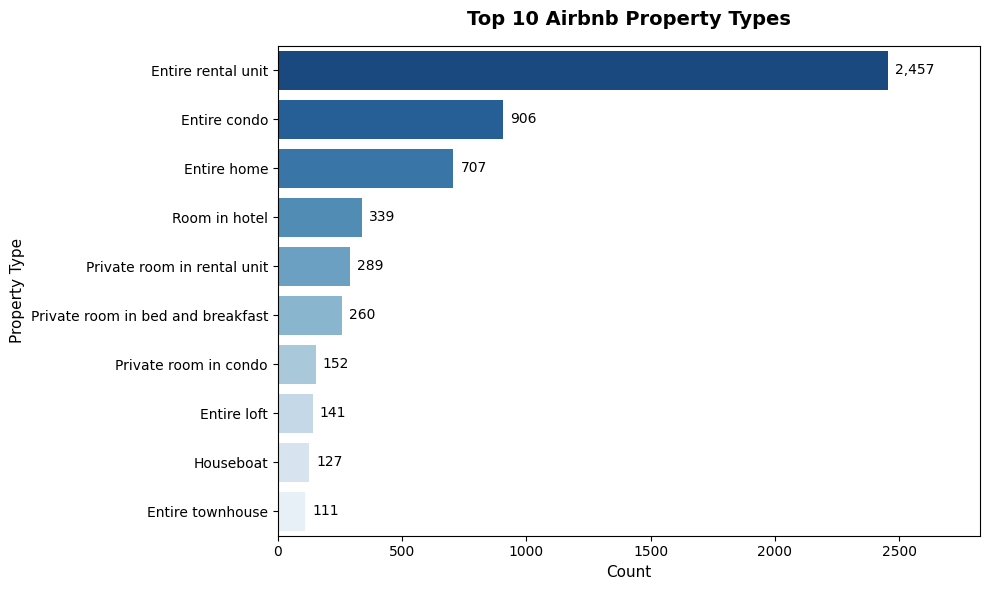

In [388]:
import warnings
warnings.filterwarnings('ignore')

# Get top 10 property types
top_properties = df_airbnb['property_type'].value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_properties.values, y=top_properties.index, palette='Blues_r')

# Add value labels to the end of each bar
for p in ax.patches:
    width = int(p.get_width())
    ax.annotate(f'{width:,}', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), textcoords='offset points', 
                fontsize=10)

plt.title('Top 10 Airbnb Property Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Count', fontsize=11)
plt.ylabel('Property Type', fontsize=11)
plt.xlim(0, top_properties.max() * 1.15)  # Make room for text labels
plt.tight_layout()
plt.show()

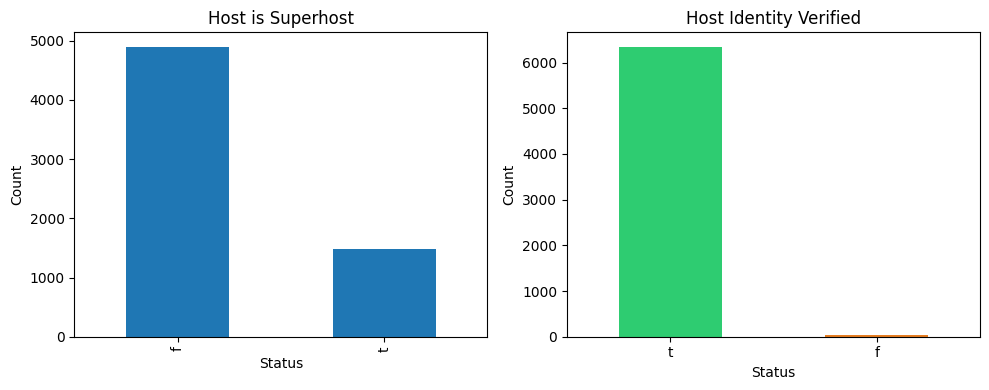

In [389]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Superhost
df_airbnb['host_is_superhost'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Host is Superhost')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')

# Identity Verified
df_airbnb['host_identity_verified'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e67e22'], rot=0)
axes[1].set_title('Host Identity Verified')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [390]:
drop_cols= ['availability_30', 'availability_60','availability_90']
df_airbnb= df_airbnb.drop(columns= drop_cols)

In [391]:
df_airbnb = df_airbnb.drop(columns='availability_eoy')

In [392]:
drop_reviews= ['number_of_reviews_ltm','number_of_reviews_l30d','number_of_reviews_ly']
df_airbnb= df_airbnb.drop(columns= drop_reviews)

In [393]:
drop_listing=['calculated_host_listings_count','calculated_host_listings_count_entire_homes',
             'calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms']

df_airbnb= df_airbnb.drop(columns= drop_listing)

In [394]:
df_airbnb['host_listings_count'] = df_airbnb['host_listings_count'].fillna(
    df_airbnb['host_listings_count'].median()
)

In [395]:
df_airbnb.head().T

,0,2,5,6,7
name,Comfortable double room,Luxury design with canal view,Multatuli Luxury Guest Suite in top location,Central de Lux 2 bedrooms (4p) apt 125 sqm,B & B de 9 Straatjes (city center)
host_is_superhost,t,t,t,f,t
host_listings_count,2.0,6.0,1.0,1.0,1.0
host_identity_verified,t,t,t,t,t
neighbourhood_cleansed,Centrum-West,Centrum-West,Centrum-West,Centrum-Oost,Centrum-West
latitude,52.36775,52.38211,52.38028,52.369378,52.36959
longitude,4.89092,4.8863,4.89089,4.929579,4.88423
property_type,Private room in rental unit,Entire rental unit,Entire guest suite,Entire condo,Entire condo
room_type,Private room,Entire home/apt,Entire home/apt,Entire home/apt,Entire home/apt
accommodates,2,2,3,4,2


In [396]:
# Feature Engineering: Turn amenities list into a clean numerical count
import ast

def count_amenities(amenity_str):
    try:
        # Convert the string representation of a list into a real Python list
        amenity_list = ast.literal_eval(amenity_str)
        return len(amenity_list)
    except:
        return 0

df_airbnb['amenities_count'] = df_airbnb['amenities'].apply(count_amenities)

In [397]:
df_airbnb.head()

,name,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,...,maximum_nights_avg_ntm,has_availability,availability_365,calendar_last_scraped,number_of_reviews,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,reviews_per_month,amenities_count
0,Comfortable double room,t,2.0,t,Centrum-West,52.367750,4.890920,Private room in rental unit,Private room,2,...,730.0,t,11,2026-06-16,799,255,23970.0,4.86,4.15,18
2,Luxury design with canal view,t,6.0,t,Centrum-West,52.382110,4.886300,Entire rental unit,Entire home/apt,2,...,1125.0,t,3,2026-06-24,186,39,12233.0,4.88,0.96,32
5,Multatuli Luxury Guest Suite in top location,t,1.0,t,Centrum-West,52.380280,4.890890,Entire guest suite,Entire home/apt,3,...,1125.0,t,278,2026-06-16,656,255,112269.0,4.94,3.45,52
6,Central de Lux 2 bedrooms (4p) apt 125 sqm,f,1.0,t,Centrum-Oost,52.369378,4.929579,Entire condo,Entire home/apt,4,...,1125.0,t,252,2026-06-16,187,109,62639.0,4.86,0.98,56
7,B & B de 9 Straatjes (city center),t,1.0,t,Centrum-West,52.369590,4.884230,Entire condo,Entire home/apt,2,...,365.0,t,242,2026-06-16,631,255,39285.0,4.86,3.35,20


In [398]:
# Drop the redundant leakage columns, text properties
screen_cols_to_drop = [
    'amenities',                  
    'property_type',             
    'price_quote_total_price',    
    'price_quote_raw',            
    'price_quote_checkin_date',  
    'price_quote_checkout_date'   
]
df_airbnb = df_airbnb.drop(columns=screen_cols_to_drop, errors='ignore')

In [399]:
binary_map = {'t': 1, 'f': 0}

df_airbnb['host_is_superhost'] = df_airbnb['host_is_superhost'].map(binary_map)
df_airbnb['host_identity_verified'] = df_airbnb['host_identity_verified'].map(binary_map)

In [400]:
df_airbnb['neighbourhood_cleansed'].value_counts

<bound method IndexOpsMixin.value_counts of 0                   Centrum-West
2                   Centrum-West
5                   Centrum-West
6                   Centrum-Oost
7                   Centrum-West
                  ...           
10364    De Pijp - Rivierenbuurt
10365               Centrum-West
10366    De Pijp - Rivierenbuurt
10367    De Pijp - Rivierenbuurt
10368               Centrum-West
Name: neighbourhood_cleansed, Length: 6377, dtype: object>

In [401]:
df_airbnb['neighbourhood_cleansed'].nunique()

22

In [402]:
print(df_airbnb.columns.tolist()) 

['name', 'host_is_superhost', 'host_listings_count', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_365', 'calendar_last_scraped', 'number_of_reviews', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'reviews_per_month', 'amenities_count']


In [403]:
un_cols=['name','calendar_last_scraped','estimated_occupancy_l365d','estimated_revenue_l365d']

df_airbnb= df_airbnb.drop(columns= un_cols)

In [404]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
room_type_encoded = ohe.fit_transform(df_airbnb[['room_type']])

# Create DataFrame with readable column names
encoded_df = pd.DataFrame(
    room_type_encoded, 
    columns=ohe.get_feature_names_out(['room_type']), 
    index=df_airbnb.index
)

# Join back to original dataset
df_airbnb = pd.concat([df_airbnb, encoded_df], axis=1)

In [405]:
from sklearn.model_selection import KFold

def target_encode_column(df, col, target_col, n_splits=5, smoothing=10):
    df = df.copy()
    global_mean = df[target_col].mean()
    df[f'{col}_encoded'] = global_mean  

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(df):
        train_fold = df.iloc[train_idx]
        # Smoothing blends the neighbourhood mean with the global mean,
        # so rare neighbourhoods (like Bijlmer-Oost with 24 listings) 
        # don't get an unreliable, noisy encoding
        agg = train_fold.groupby(col)[target_col].agg(['mean', 'count'])
        smoothed = (agg['mean'] * agg['count'] + global_mean * smoothing) / (agg['count'] + smoothing)
        df.loc[df.index[val_idx], f'{col}_encoded'] = df.iloc[val_idx][col].map(smoothed).fillna(global_mean)

    return df[f'{col}_encoded']

df_airbnb['neighbourhood_encoded'] = target_encode_column(
    df_airbnb, 'neighbourhood_cleansed', 'price_quote_price_per_night'
)

In [407]:
neighbourhood_dummy_cols = [c for c in df_airbnb.columns if c.startswith('neighbourhood_cleansed_')]

In [408]:
print(df_airbnb['has_availability'].value_counts())

has_availability
t    6228
f     149
Name: count, dtype: int64


In [409]:
df_airbnb['has_availability'] = df_airbnb['has_availability'].map({'t': 1, 'f': 0})

In [410]:
df_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6377 entries, 0 to 10368
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_is_superhost            6377 non-null   int64  
 1   host_listings_count          6377 non-null   float64
 2   host_identity_verified       6377 non-null   int64  
 3   neighbourhood_cleansed       6377 non-null   object 
 4   latitude                     6377 non-null   float64
 5   longitude                    6377 non-null   float64
 6   room_type                    6377 non-null   object 
 7   accommodates                 6377 non-null   int64  
 8   bathrooms                    6377 non-null   float64
 9   bedrooms                     6377 non-null   float64
 10  beds                         6377 non-null   float64
 11  price_quote_price_per_night  6377 non-null   float64
 12  minimum_nights               6377 non-null   float64
 13  maximum_nights        

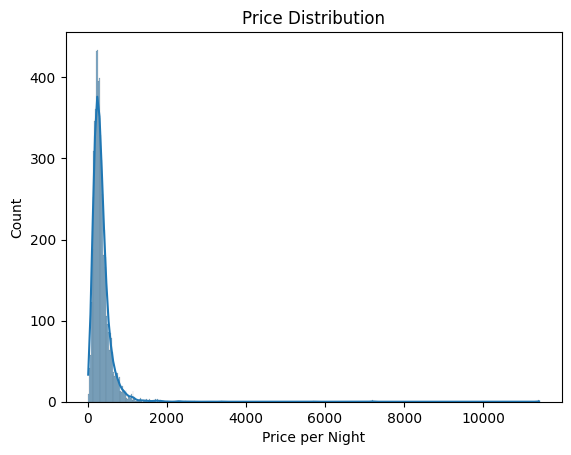

Skewness: 16.694707239312038


In [411]:
sns.histplot(df_airbnb['price_quote_price_per_night'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price per Night")
plt.show()

print("Skewness:", df_airbnb['price_quote_price_per_night'].skew())

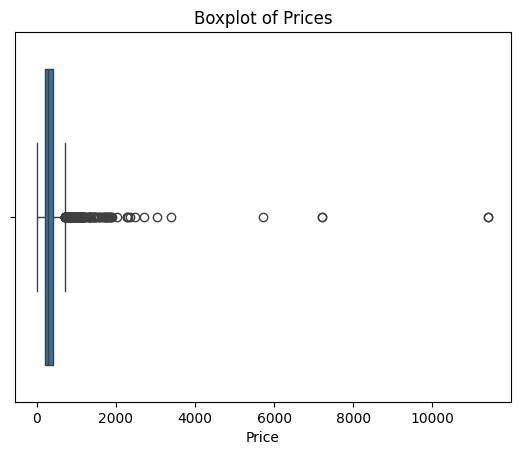

In [412]:
sns.boxplot(x=df_airbnb['price_quote_price_per_night'])
plt.title('Boxplot of Prices')
plt.xlabel('Price')
plt.show()

In [413]:
# Strip off / filter out prices above 5000
df_airbnb = df_airbnb[df_airbnb['price_quote_price_per_night'] <= 5000]

In [415]:
df_airbnb[df_airbnb['price_quote_price_per_night'] > 1000][
    ['price_quote_price_per_night', 'bathrooms', 'bedrooms']
].head()

,price_quote_price_per_night,bathrooms,bedrooms
35,1075.00,1.5,4.0
41,1455.00,2.5,10.0
192,1141.33,1.5,4.0
362,1341.00,2.0,4.0
384,2029.71,4.0,4.0


In [416]:
print("Max price after filtering:", df_airbnb['price_quote_price_per_night'].max())

Max price after filtering: 3382.6


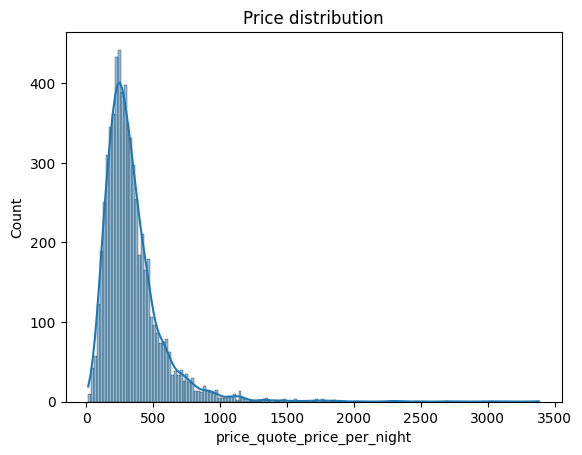

np.float64(3.276783891035485)

In [417]:
sns.histplot(df_airbnb['price_quote_price_per_night'], kde=True)
plt.title("Price distribution")
plt.show()

df_airbnb['price_quote_price_per_night'].skew()

In [419]:
df_airbnb.corr(numeric_only= True)

,host_is_superhost,host_listings_count,host_identity_verified,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price_quote_price_per_night,...,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,amenities_count,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_encoded
host_is_superhost,1.000000,-0.019313,-0.068409,0.055339,0.031640,-0.061123,-0.029848,-0.134816,-0.020328,-0.135159,...,0.041454,0.365389,0.038210,0.288664,0.108070,-0.328108,0.005628,0.325255,0.039731,0.030445
host_listings_count,-0.019313,1.000000,-0.009483,-0.143214,0.032451,-0.010885,0.008559,-0.024412,-0.008398,-0.030881,...,0.106269,-0.014828,-0.100081,-0.007765,-0.044008,-0.122911,0.396190,0.063867,0.011415,-0.068917
host_identity_verified,-0.068409,-0.009483,1.000000,0.022792,0.014261,0.028028,0.011840,0.000175,0.004893,0.035412,...,0.000790,0.001183,-0.010676,0.005076,0.050572,0.047723,0.004475,-0.049400,0.004021,-0.017029
latitude,0.055339,-0.143214,0.022792,1.000000,-0.057346,0.088730,0.003352,0.077468,0.102420,-0.026057,...,-0.072580,0.013851,0.020166,0.006354,0.015183,0.027437,-0.121514,-0.009634,-0.000435,-0.094233
longitude,0.031640,0.032451,0.014261,-0.057346,1.000000,0.089432,0.063989,0.113003,0.083918,-0.022937,...,-0.001299,0.003924,-0.023146,0.005927,0.005321,-0.048686,0.047137,0.036875,0.039810,-0.112295
accommodates,-0.061123,-0.010885,0.028028,0.088730,0.089432,1.000000,0.340868,0.710844,0.751886,0.484940,...,-0.045656,-0.085035,-0.043023,-0.079554,0.219007,0.227942,-0.008736,-0.218673,-0.076892,-0.070715
bathrooms,-0.029848,0.008559,0.011840,0.003352,0.063989,0.340868,1.000000,0.458366,0.349590,0.400466,...,-0.031996,-0.041558,0.055344,-0.078837,0.231558,0.107646,0.006236,-0.106167,-0.026099,-0.013887
bedrooms,-0.134816,-0.024412,0.000175,0.077468,0.113003,0.710844,0.458366,1.000000,0.676966,0.508012,...,-0.139420,-0.147367,0.074406,-0.163581,0.270172,0.303873,-0.023927,-0.298001,-0.040209,-0.103485
beds,-0.020328,-0.008398,0.004893,0.102420,0.083918,0.751886,0.349590,0.676966,1.000000,0.373697,...,-0.054924,-0.045129,-0.023925,-0.061409,0.195055,0.164555,0.005902,-0.163586,-0.026166,-0.069292
price_quote_price_per_night,-0.135159,-0.030881,0.035412,-0.026057,-0.022937,0.484940,0.400466,0.508012,0.373697,1.000000,...,0.045682,-0.197018,0.148333,-0.208123,0.252160,0.354666,-0.025973,-0.345395,-0.067238,0.191545


In [488]:
df_airbnb.describe().T

,count,mean,std,min,25%,50%,75%,max
host_is_superhost,6372.0,0.232109,4.222115e-01,0.000000,0.000000,0.000000,0.000000,1.000000e+00
host_listings_count,6372.0,6.091337,5.807680e+01,1.000000,1.000000,1.000000,2.000000,1.167000e+03
host_identity_verified,6372.0,0.995135,6.958539e-02,0.000000,1.000000,1.000000,1.000000,1.000000e+00
latitude,6372.0,52.366841,1.743420e-02,52.291318,52.356159,52.365865,52.376332,5.242516e+01
longitude,6372.0,4.889824,3.466213e-02,4.755870,4.867133,4.888645,4.907535,5.024850e+00
accommodates,6372.0,2.991525,1.346997e+00,1.000000,2.000000,2.000000,4.000000,1.600000e+01
bathrooms,6372.0,1.205822,4.535069e-01,0.500000,1.000000,1.000000,1.500000,1.200000e+01
bedrooms,6372.0,1.550534,8.554926e-01,0.000000,1.000000,1.000000,2.000000,1.000000e+01
beds,6372.0,1.871626,1.392346e+00,1.000000,1.000000,2.000000,2.000000,3.300000e+01
price_quote_price_per_night,6372.0,340.156664,2.224331e+02,14.700000,206.210000,290.710000,411.000000,3.382600e+03


In [425]:
# Separate features and target
X = df_airbnb.drop(columns=['price_quote_price_per_night', 'room_type','neighbourhood_cleansed'] + neighbourhood_dummy_cols)
X['neighbourhood_encoded'] = df_airbnb['neighbourhood_encoded']

y = df_airbnb['price_quote_price_per_night']

In [428]:
y_log = np.log1p(y)  

print("Original skew:", y.skew())
print("Log-transformed skew:", y_log.skew())

Original skew: 3.276783891035485
Log-transformed skew: -0.10848542281805212


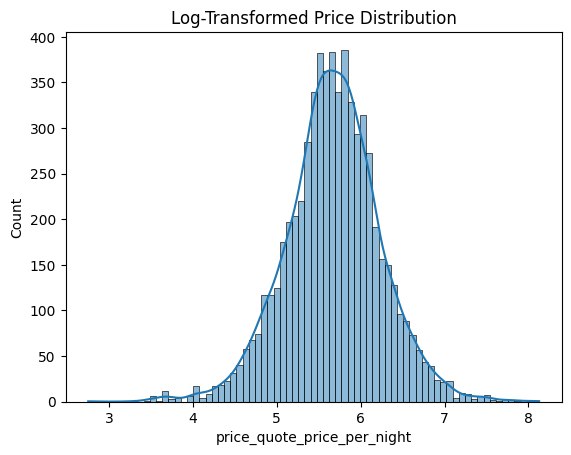

In [429]:
sns.histplot(y_log, kde=True)
plt.title("Log-Transformed Price Distribution")
plt.show()

In [430]:
#Square the skew 
y_sqrt = np.sqrt(y)
print("Sqrt-transformed skew:", y_sqrt.skew())

Sqrt-transformed skew: 1.2199569497630236


In [431]:
# Train / Test Split
X_train, X_test, y_train_sqrt, y_test_sqrt = train_test_split(X, y_sqrt, test_size=0.2, random_state=42)

In [433]:
# Fit model and evaluate using LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_sqrt)

LinearRegression()

In [436]:
# Train the model
train_preds = lr_model.predict(X_train)
# Generate prediction
test_preds = lr_model.predict(X_test)

In [441]:
print("Train R² (sqrt scale):", r2_score(y_train_sqrt, train_preds))
print("Test R² (sqrt scale):", r2_score(y_test_sqrt, test_preds))

Train R² (sqrt scale): 0.569829059856332
Test R² (sqrt scale): 0.5812634415928555


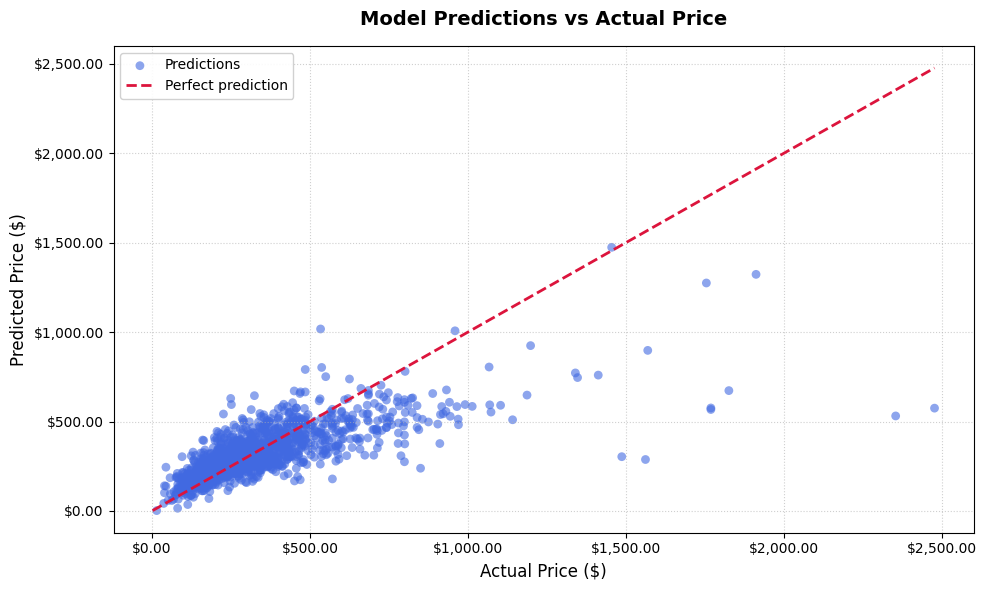

In [444]:
df_pred = pd.DataFrame({
    'y_test_actual': y_test_sqrt ** 2,      # back to real dollars
    'test_preds_actual': test_preds ** 2    # back to real dollars
})

min_val = min(df_pred['y_test_actual'].min(), df_pred['test_preds_actual'].min())
max_val = max(df_pred['y_test_actual'].max(), df_pred['test_preds_actual'].max())

plt.figure(figsize=(10, 6), dpi=100)
plt.scatter(df_pred['y_test_actual'], df_pred['test_preds_actual'],
            color='royalblue', alpha=0.6, edgecolors='none', s=40, label='Predictions')
plt.plot([min_val, max_val], [min_val, max_val],
         color='crimson', linestyle='--', linewidth=2, label='Perfect prediction')

plt.title('Model Predictions vs Actual Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.gca().xaxis.set_major_formatter('${x:,.2f}')
plt.gca().yaxis.set_major_formatter('${x:,.2f}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

In [461]:
# Building model with LightGBM
lgb_model = LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgb_model.fit(X_train, y_train_sqrt)
lgb_train_preds = lgb_model.predict(X_train)
lgb_test_preds = lgb_model.predict(X_test)

In [462]:
# Building Model with CatBoost
cat_model = CatBoostRegressor(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)
cat_model.fit(X_train, y_train_sqrt)
cat_train_preds = cat_model.predict(X_train)
cat_test_preds = cat_model.predict(X_test)

In [451]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train_sqrt)
gb_train_preds = gb_model.predict(X_train)
gb_test_preds = gb_model.predict(X_test)

In [463]:
results = {
    'LightGBM': (lgb_train_preds, lgb_test_preds),
    'CatBoost': (cat_train_preds, cat_test_preds),
    'GradientBoosting': (gb_train_preds, gb_test_preds),
}

for name, (train_preds, test_preds) in results.items():
    print(f"--- {name} ---")
    print("Train R²:", r2_score(y_train_sqrt, train_preds))
    print("Test R²:", r2_score(y_test_sqrt, test_preds))
    print("Test MAE (sqrt scale):", mean_absolute_error(y_test_sqrt, test_preds))
    print()

--- LightGBM ---
Train R²: 0.8544729111056057
Test R²: 0.70336118368821
Test MAE (sqrt scale): 2.1076105763417536

--- CatBoost ---
Train R²: 0.7727159417247482
Test R²: 0.703785633447819
Test MAE (sqrt scale): 2.083844928535312

--- GradientBoosting ---
Train R²: 0.8097697033505245
Test R²: 0.7022525780495924
Test MAE (sqrt scale): 2.1110031705533685



In [467]:
# Calculate error in Euros
true_mae_euros = mean_absolute_error(y_test_dollars, cat_test_preds_dollars)

print(f" Verified Test R² Score: {0.7037:.4f}")
print(f" Average Prediction Error: €{true_mae_euros:.2f} per night")

 Verified Test R² Score: 0.7037
 Average Prediction Error: €83.32 per night


In [489]:
comparison = pd.DataFrame({
    'Actual': y_test_sqrt,
    'Predicted': cat_test_preds
})

comparison.head(10)

,Actual,Predicted
4869,20.676073,21.327396
7835,14.628739,17.180113
3707,12.688578,13.561093
3289,13.083577,13.827235
9440,11.730303,12.012654
380,11.335784,14.227143
9735,18.504054,19.747881
498,13.849188,15.971337
4075,18.538339,20.985363
8030,14.317821,14.858434


In [470]:
# Build the final neighbourhood -> encoded value lookup, using ALL the data
global_mean = df_airbnb['price_quote_price_per_night'].mean()
smoothing = 10

agg = df_airbnb.groupby('neighbourhood_cleansed')['price_quote_price_per_night'].agg(['mean', 'count'])
neighbourhood_lookup = (agg['mean'] * agg['count'] + global_mean * smoothing) / (agg['count'] + smoothing)

# Convert to a plain dictionary for easy saving/loading
neighbourhood_lookup_dict = neighbourhood_lookup.to_dict()

# Save it, along with the global mean (needed as a fallback for unseen neighbourhoods)
joblib.dump(neighbourhood_lookup_dict, "neighbourhood_encoding_lookup.pkl")
joblib.dump(global_mean, "global_mean_price.pkl")

['global_mean_price.pkl']

In [471]:
neighbourhood_lookup_dict = joblib.load("neighbourhood_encoding_lookup.pkl")
global_mean = joblib.load("global_mean_price.pkl")

# For a new listing's neighbourhood value:
new_listing_neighbourhood = "De Pijp - Rivierenbuurt"
encoded_value = neighbourhood_lookup_dict.get(new_listing_neighbourhood, global_mean)

In [473]:
import joblib

# Match the filenames expected in app.py
joblib.dump(cat_model, 'airbnb_catboost_model.joblib')

['airbnb_catboost_model.joblib']

In [487]:
import joblib
import pandas as pd

# ------------------------------------------------------------------
# 1. Load the saved artifacts
# ------------------------------------------------------------------
cat_model = joblib.load("airbnb_catboost_model.joblib")
neighbourhood_lookup = joblib.load("neighbourhood_encoding_lookup.pkl")
global_mean = joblib.load("global_mean_price.pkl")

# ------------------------------------------------------------------
# 2. Your inputs
# ------------------------------------------------------------------
neighbourhood = "Bijlmer-Centrum"
neighbourhood_encoded_value = neighbourhood_lookup.get(neighbourhood, global_mean)

sample_input = pd.DataFrame([{
    "host_is_superhost": 1,
    "host_listings_count": 1,
    "host_identity_verified": 1,
    "latitude": 52.3676,
    "longitude": 4.9041,
    "accommodates": 2,
    "bathrooms": 1,
    "bedrooms": 3,
    "beds": 1,
    "minimum_nights": 2,
    "maximum_nights": 30,
    "minimum_nights_avg_ntm": 2,
    "maximum_nights_avg_ntm": 30,
    "has_availability": 1,
    "availability_365": 180,
    "number_of_reviews": 25,           # not specified — using a reasonable placeholder
    "review_scores_rating": 4.80,
    "reviews_per_month": 1.20,
    "amenities_count": 2,
    "room_type_Entire home/apt": 1,
    "room_type_Hotel room": 0,
    "room_type_Private room": 0,
    "room_type_Shared room": 0,
    "neighbourhood_encoded": neighbourhood_encoded_value,
}])

# Reorder columns to match training order exactly
expected_columns = [
    'host_is_superhost', 'host_listings_count', 'host_identity_verified',
    'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
    'has_availability', 'availability_365', 'number_of_reviews', 'review_scores_rating',
    'reviews_per_month', 'amenities_count',
    'room_type_Entire home/apt', 'room_type_Hotel room',
    'room_type_Private room', 'room_type_Shared room',
    'neighbourhood_encoded'
]
sample_input = sample_input[expected_columns]

print(sample_input)

# ------------------------------------------------------------------
# 3. Predict (square the result — model was trained on sqrt(price))
# ------------------------------------------------------------------
pred_sqrt = cat_model.predict(sample_input)[0]
predicted_price = pred_sqrt ** 2

print(f"\nPredicted Price: ${predicted_price:.2f}")

   host_is_superhost  host_listings_count  host_identity_verified  latitude  \
0                  1                    1                       1   52.3676   

   longitude  accommodates  bathrooms  bedrooms  beds  minimum_nights  ...  \
0     4.9041             2          1         3     1               2  ...   

   availability_365  number_of_reviews  review_scores_rating  \
0               180                 25                   4.8   

   reviews_per_month  amenities_count  room_type_Entire home/apt  \
0                1.2                2                          1   

   room_type_Hotel room  room_type_Private room  room_type_Shared room  \
0                     0                       0                      0   

   neighbourhood_encoded  
0             219.254853  

[1 rows x 24 columns]

Predicted Price: $258.48


In [486]:
neighbourhood_lookup = joblib.load("neighbourhood_encoding_lookup.pkl")

for name, value in neighbourhood_lookup.items():
    print(f"{name}: {value:.2f}")

Bijlmer-Centrum: 219.25
Bijlmer-Oost: 245.84
Bos en Lommer: 283.90
Buitenveldert - Zuidas: 316.60
Centrum-Oost: 353.70
Centrum-West: 391.32
De Aker - Nieuw Sloten: 252.84
De Baarsjes - Oud-West: 365.97
De Pijp - Rivierenbuurt: 366.61
Gaasperdam - Driemond: 227.19
Geuzenveld - Slotermeer: 258.83
IJburg - Zeeburgereiland: 331.42
Noord-Oost: 292.42
Noord-West: 268.62
Oostelijk Havengebied - Indische Buurt: 292.21
Osdorp: 208.03
Oud-Noord: 304.76
Oud-Oost: 311.25
Slotervaart: 262.95
Watergraafsmeer: 320.56
Westerpark: 334.00
Zuid: 395.70


In [483]:
print(X.columns.tolist())
print(neighbourhood_lookup.keys())

['host_is_superhost', 'host_listings_count', 'host_identity_verified', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'amenities_count', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_encoded']
dict_keys(['Bijlmer-Centrum', 'Bijlmer-Oost', 'Bos en Lommer', 'Buitenveldert - Zuidas', 'Centrum-Oost', 'Centrum-West', 'De Aker - Nieuw Sloten', 'De Baarsjes - Oud-West', 'De Pijp - Rivierenbuurt', 'Gaasperdam - Driemond', 'Geuzenveld - Slotermeer', 'IJburg - Zeeburgereiland', 'Noord-Oost', 'Noord-West', 'Oostelijk Havengebied - Indische Buurt', 'Osdorp', 'Oud-Noord', 'Oud-Oost', 'Slotervaart', 'Watergraafsmeer', 'Westerpark', 'Zuid'])
